# 导入数据

In [34]:
# import kagglehub

# # Download latest version
# path = kagglehub.competition_download('cowboyoutfits',output_dir='./data') 
# print("Path to competition files:", path)

In [35]:
# !pip install pycocotools
# !pip install d2l --no -deps

In [45]:
import os
from pathlib import Path
from pycocotools.coco import COCO

DATA_DIR = Path("data")
IMAGE_DIR = DATA_DIR / "images"
ANN_FILE = DATA_DIR / "train.json"

coco = COCO(str(ANN_FILE))

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!


In [46]:
print('图片数量：',len(coco.imgs))
print('标注数量：',len(coco.anns))
print('类别数量：',len(coco.cats))

图片数量： 3062
标注数量： 5594
类别数量： 5


In [47]:
categories = coco.loadCats(coco.getCatIds())

for category in categories:
    print(
        "类别 ID：", category["id"],
        "类别名称：", category["name"]
    )

类别 ID： 87 类别名称： belt
类别 ID： 1034 类别名称： sunglasses
类别 ID： 131 类别名称： boot
类别 ID： 318 类别名称： cowboy_hat
类别 ID： 588 类别名称： jacket


In [48]:
id_to_name = {
    category['id'] : category['name']
    for category in categories
}
id_to_name

{87: 'belt', 1034: 'sunglasses', 131: 'boot', 318: 'cowboy_hat', 588: 'jacket'}

{'id': 9860841628484337660, 'file_name': '88d8bf3754317ffc.jpg', 'neg_category_ids': [434], 'pos_category_ids': [69, 161, 216, 277, 433], 'width': 1024, 'height': 681, 'source': 'OpenImages'}


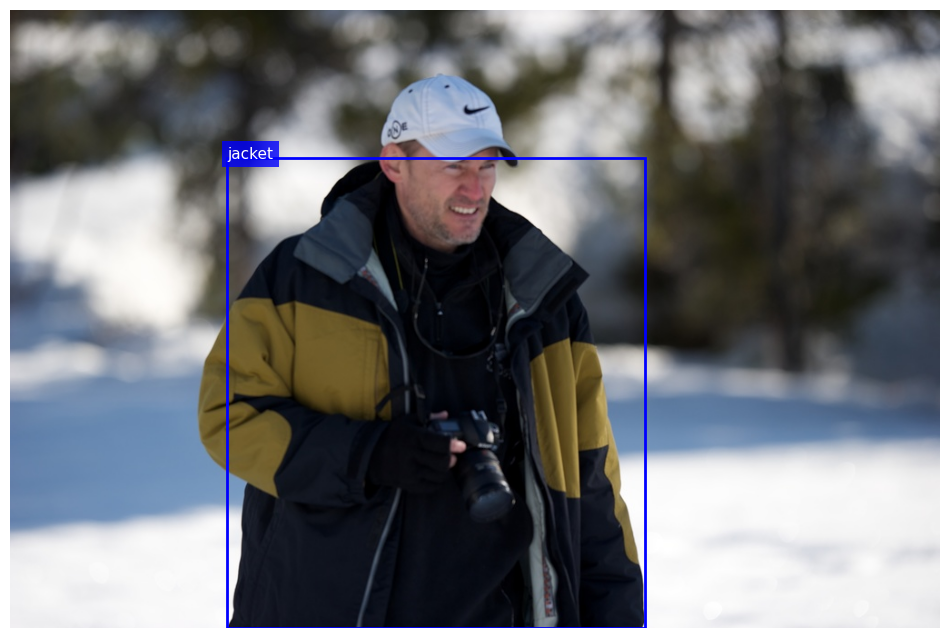

In [49]:
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

img_id = coco.getImgIds()[0]

img_info = coco.loadImgs([img_id])[0]
print(img_info)


ann_ids = coco.getAnnIds(imgIds=img_id)
annotations = coco.loadAnns(ann_ids)

image_path = IMAGE_DIR / img_info["file_name"]
image = Image.open(image_path).convert("RGB")

fig, ax = plt.subplots(figsize=(12, 9))
ax.imshow(image)


for ann in annotations:
    x, y, width, height = ann["bbox"]

    category = coco.loadCats([ann["category_id"]])[0]
    category_name = category["name"]

    rectangle = patches.Rectangle(
        (x, y),          # 左上角
        width,           # 宽度
        height,          # 高度
        linewidth=2,
        edgecolor="blue",
        facecolor="none"
    )

    ax.add_patch(rectangle)

    ax.text(
        x,
        y,
        category_name,
        color="white",
        fontsize=11,
        bbox={
            "facecolor": "blue",
            "alpha": 0.8,
            "edgecolor": "none"
        }
    )

ax.axis("off")
plt.show()


## EDA

In [50]:
import pandas as pd

statistics = []

for category in categories:
    ann_ids = coco.getAnnIds(
        catIds=[category["id"]]
    )

    statistics.append({
        "category_id": category["id"],
        "category_name": category["name"],
        "instance_count": len(ann_ids)
    })

count_df = pd.DataFrame(statistics)
count_df = count_df.sort_values(
    "instance_count",
    ascending=False
).reset_index(drop=True)

display(count_df)

,category_id,category_name,instance_count
0,1034,sunglasses,2330
1,588,jacket,2195
2,318,cowboy_hat,595
3,131,boot,449
4,87,belt,25


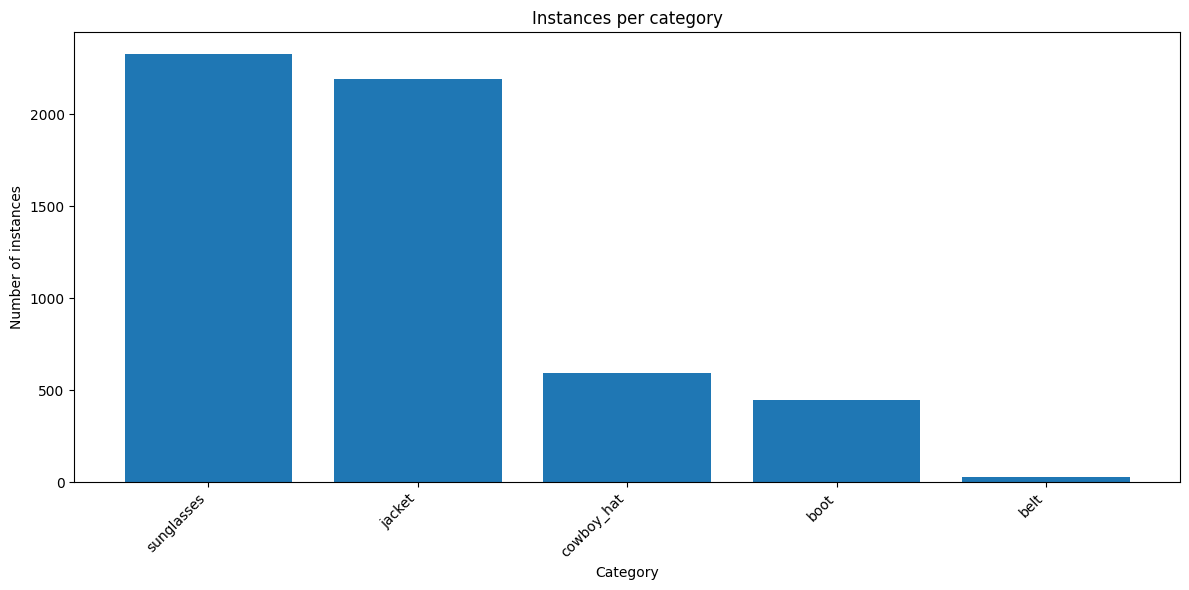

In [51]:
plt.figure(figsize=(12, 6))

plt.bar(
    count_df["category_name"],
    count_df["instance_count"]
)

plt.xlabel("Category")
plt.ylabel("Number of instances")
plt.title("Instances per category")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

标签不平衡，如果直接训练模型，很有可能对实例少的类预测效果不好

## 定义 Dataset

In [ ]:
from cProfile import label
from torch.utils.data import Dataset,DataLoader
import torch 
from torchvision.transforms.functional import pil_to_tensor
from torchvision import transforms
# torchvision 检测模型规定：
# 0 表示背景，真实类别从 1 开始
category_ids = sorted(coco.getCatIds())

category_to_label = {
    category_id: label
    for label, category_id in enumerate(category_ids, start=1)
}

label_to_name = {
    label: coco.cats[category_id]["name"]
    for category_id, label in category_to_label.items()
}


class CowBoyDataset(Dataset):
    def __init__(self,coco,image_dir,transform=None):
        self.coco = coco
        self.image_dir = image_dir
        self.image_ids = sorted(coco.getImgIds())
        self.transform = transform

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, index):
        origin_image_id = self.image_ids[index]

        image_info = self.coco.loadImgs([origin_image_id])[0]
        image_path = os.path.join(self.image_dir,image_info['file_name'])

        image = Image.open(image_path).convert('RGB')
        image = pil_to_tensor(image).float() / 255.0

        annotation_ids = self.coco.getAnnIds(
            imgIds=[origin_image_id]
        )

        annotations = self.coco.loadAnns(annotation_ids)

        boxes = []
        labels = []
        iscrowd = []

        for annotation in annotations:
            # COCO: [x, y, width, height]
            x, y, width, height = annotation["bbox"]

            # torchvision: [x1, y1, x2, y2]
            boxes.append([
                x,
                y,
                x + width,
                y + height
            ])


            labels.append(category_to_label[annotation['category_id']])
            iscrowd.append(
                int(annotation.get("iscrowd", 0))
            )
        
        boxes = torch.tensor(boxes, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.int64)
        iscrowd = torch.tensor(iscrowd, dtype=torch.int64)

        area = (
            (boxes[:, 2] - boxes[:, 0])
            * (boxes[:, 3] - boxes[:, 1])
        )

        target = {
            "boxes": boxes,
            "labels": labels,
            # 原始 COCO ID 有些超过 int64 范围，所以这里使用数据集下标
            "image_id": torch.tensor(index, dtype=torch.int64),
            "area": area,
            "iscrowd": iscrowd
        }   

        if self.transform is not None:
            image, target = self.transform(image, target)

        return image, target
        

In [61]:
full_dataset = CowBoyDataset(coco,IMAGE_DIR)

image,target = full_dataset[0]

print(image)
print(target)

tensor([[[0.5059, 0.5098, 0.5098,  ..., 0.7059, 0.7451, 0.7765],
         [0.5098, 0.5137, 0.5098,  ..., 0.7294, 0.7804, 0.8118],
         [0.5098, 0.5098, 0.5020,  ..., 0.7608, 0.8118, 0.8471],
         ...,
         [0.0627, 0.0980, 0.1176,  ..., 0.8510, 0.8392, 0.8392],
         [0.0667, 0.1020, 0.1216,  ..., 0.8353, 0.8392, 0.8588],
         [0.0745, 0.1059, 0.1255,  ..., 0.8431, 0.8275, 0.8588]],

        [[0.4510, 0.4471, 0.4471,  ..., 0.6510, 0.6941, 0.7373],
         [0.4471, 0.4510, 0.4471,  ..., 0.6745, 0.7294, 0.7725],
         [0.4471, 0.4471, 0.4392,  ..., 0.7059, 0.7608, 0.8078],
         ...,
         [0.0588, 0.0902, 0.1098,  ..., 0.8039, 0.8078, 0.8039],
         [0.0627, 0.0941, 0.1137,  ..., 0.7804, 0.7922, 0.8118],
         [0.0706, 0.0980, 0.1176,  ..., 0.7882, 0.7804, 0.8118]],

        [[0.4000, 0.3961, 0.3961,  ..., 0.6157, 0.6588, 0.7020],
         [0.3961, 0.4000, 0.3961,  ..., 0.6392, 0.6941, 0.7373],
         [0.3961, 0.3961, 0.3882,  ..., 0.6706, 0.7255, 0.

In [ ]:
train_transform = transforms.Compose(
    transforms.RandomResizedCrop(size=224)
    transforms.
)

NameError: name 'transform' is not defined